### Project #4 - Geopandas: Mapping with Python
In this lab we'll learn how to use maps within Python, no ArcGIS needed.

In [1]:
## Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from PIL import Image
from IPython.display import display

#### Creating a basic map in Geopandas
In order to map with Geopandas, we need what's called a "spatial variable".  A spatial variable can be latitude and longitude, a SHP file like from ArcGIS or a geoID that tells a system like Geopandas where specific data needs to go on built in maps.

In our NRI data set, we have either:
1. County Level Data
2. Census Tract Data

For the purposes of plotting, we can use either, but we'll use Census Tract data to plot for this lab.  Feel free to explore how to do mapping with County Level Data on your own.  Download the SHP file from the CDC website.  You also need all the other files in the download, so make sure all those files are in your working directory.

In [1]:
## Read the Census Tracts data


##Verifications for Shape files


###This checks for Coordinate Reference System (CRS)

###Checks the geometries in the data


##### Clean data for mapping
When mapping, cleaning data is a bit different.  We need to check for the following items:
1. Does the data have the correct projection? - Data can be mapped to different types of maps and you always need to check that the latitude and the longitude are in the correct projection.
2. Does the data have NAs or odd features? - Latitude and longitude data does not always contain NAs, sometimes it has NaNs or weird numeric placeholders.  In our data we have -9999 as a placeholder.  We need to remove or convert these before we can map.

In [2]:
### Cleaning data - Dr. Lane's Example

# Check the projection and set it


# 3. Now you can transform to a new CRS (e.g., Pseudo-Mercator)


# Replace -9999 nulls with NaN



In [4]:
### Check data


In [5]:
# 1. Tell GeoPandas the data is actually Web Mercator (meters)

# 2. Now properly convert it to degrees to match your xlim/ylim


# Standard projection for US National maps





### First Map - NRI Risk in the United States
Using the SHP file, map the NRI value for the entire United States using the `RISK_SCORE` in the data set.

In [1]:
### Print out your census tracts



In [8]:
# List of states/territories to exclude - we are going to focus on the lower 48 to make a more condensed map
exclude = ['Alaska', 'Hawaii', 'Puerto Rico', 'American Samoa', 
           'Guam', 'Northern Mariana Islands', 'Virgin Islands']

# Filter if your column is named 'STATE'




In [2]:
### Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(18, 10))





plt.show()



NameError: name 'plt' is not defined

### Second Map - focus on Singular States
Using the same SHP file, we can filter for specific States.  In my example, I will filter for Nebraska.

In [3]:
state_name =   # <-- Change this to any state

state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

plt.show()

SyntaxError: invalid syntax (2620437107.py, line 1)

In [4]:
##  Now test if you can use a different column.


In [5]:
### Create the same plot with a different fill


### Chloropleth Maps using NRI Risk Score
Now, we need to be able to make sure we have the correct number of categories and colors to create a chloropleth map.  When you examine your data set, your goal will be to plot your risk score in comparison to the NRI risk score.  This means you need to be able to tell Geopandas which columns of the data frame to plot.  Let's try this below.

C:\Users\klane11\AppData\Local\Temp\ipykernel_23780\3646573584.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Risk Rating", loc="lower left", fontsize=9)
C:\Users\klane11\AppData\Local\Temp\ipykernel_23780\3646573584.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Risk Rating", loc="lower left", fontsize=9)


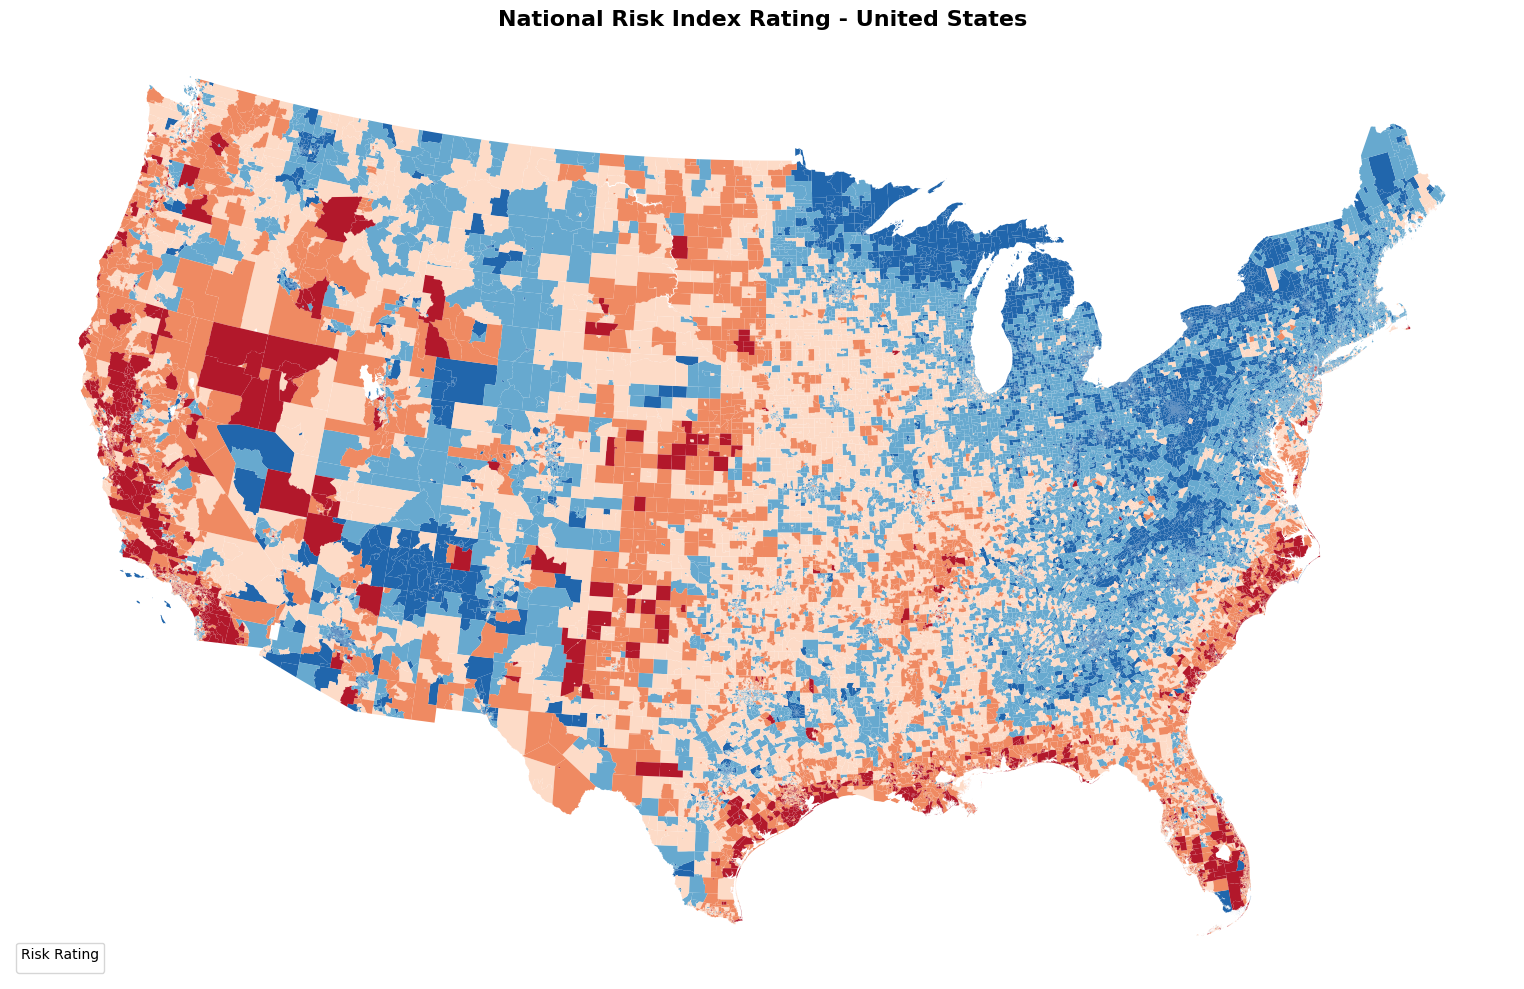

In [17]:
### Chloropleth Maps using NRI Risk Score
rating_order = ["Very Low", "Relatively Low", "Relatively Moderate", "Relatively High", "Very High"]
rating_colors = {
    "Very Low": "#2166ac",
    "Relatively Low": "#67a9cf",
    "Relatively Moderate": "#fddbc7",
    "Relatively High": "#ef8a62",
    "Very High": "#b2182b",
}

rated = tracts_lower48[tracts_lower48["RISK_RATNG"].isin(rating_order)]

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
for rating in rating_order:
    subset = rated[rated["RISK_RATNG"] == rating]
    if not subset.empty:
        subset.plot(ax=ax, color=rating_colors[rating], linewidth=0.0, label=rating)

#ax.set_xlim(-130, -65)
#ax.set_ylim(24, 50)
ax.legend(title="Risk Rating", loc="lower left", fontsize=9)
ax.set_title("National Risk Index Rating - United States", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### Lab Activities - Create 4 Maps for Project 4
In the space below, use what you learned in lab to create four maps:
1. Choose one of your states
2. Choose your two natural hazards
3. Use the NRI risk score and your risk score
You need to show 4 maps in the space below to receive credit for Lab #3 today

In [ ]:
### Students Response below





